In [249]:
from raprock.neoscan import get_objects

Let's fetch some active object:

In [250]:
objects = get_objects()
print(f"The first ten objects are:\n\n{', '.join(objects[:10])}")

The first ten objects are:

X89330, MOK0002, oDM1186, C1CA1L5, P22mlMi, ZTF10CD, C1C7FZ5, SS26D01, C1CM1G5, OEe0433


Now query for topocentrical ephemerides at LBT observatory.

In [251]:
from raprock.neoscan import get_ephemeris
from raprock.observatories import LBT

df = get_ephemeris(
    object_name="C1CM1G5",
    observatory=LBT,
    tstart="2026-03-12T18:00",
    tend="2026-03-16T18:00",
    deltat=15, # minutes
)


In [252]:
df

,Mag,Alt,Azi,Airmass,Sun_elev,SolEl,LunEl,LunPh,Phase,Glat,Glon,R,Delta,RA_deg,DEC_deg,MJD,RA_rate_deg,DEC_rate_deg,Vel_deg
0,22.3,-22.0,356.5,inf,48.6,-143.9,131.2,103.9,4.9,56.4,189.2,6.8229,5.9950,154.538138,35.333642,61111.750000,-0.000087,-0.000039,0.000096
1,22.3,-22.1,359.8,inf,50.3,-143.9,131.2,104.0,4.9,56.4,189.2,6.8229,5.9951,154.536533,35.333058,61111.760417,-0.000087,-0.000039,0.000096
2,22.3,-22.0,3.1,inf,51.7,-143.9,131.3,104.1,4.9,56.4,189.2,6.8229,5.9952,154.534925,35.332478,61111.770833,-0.000087,-0.000039,0.000096
3,22.3,-21.8,6.4,inf,52.9,-143.9,131.4,104.2,4.9,56.4,189.2,6.8229,5.9952,154.533317,35.331897,61111.781250,-0.000087,-0.000039,0.000096
4,22.3,-21.4,9.6,inf,53.7,-143.8,131.5,104.3,4.9,56.4,189.2,6.8229,5.9953,154.531713,35.331319,61111.791667,-0.000087,-0.000039,0.000096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,22.4,-20.9,347.3,inf,41.2,-140.7,159.0,150.2,5.3,56.0,189.6,6.8262,6.0268,153.930650,35.101264,61115.708333,-0.000084,-0.000043,0.000094
381,22.4,-21.5,350.6,inf,43.6,-140.7,158.9,150.3,5.3,56.0,189.6,6.8262,6.0269,153.929117,35.100619,61115.718750,-0.000084,-0.000043,0.000094
382,22.4,-22.0,353.8,inf,46.0,-140.7,158.9,150.4,5.3,56.0,189.6,6.8262,6.0270,153.927583,35.099975,61115.729167,-0.000084,-0.000043,0.000094
383,22.4,-22.2,357.1,inf,48.1,-140.7,158.8,150.4,5.3,56.0,189.6,6.8263,6.0271,153.926050,35.099331,61115.739583,-0.000084,-0.000043,0.000094


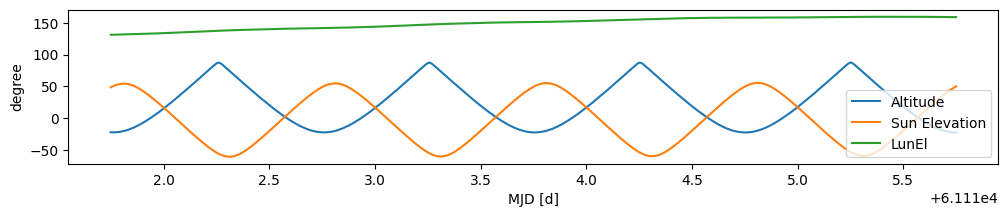

In [253]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 2))
plt.plot(df["MJD"], df["Alt"], label="Altitude")
plt.plot(df["MJD"], df["Sun_elev"], label="Sun Elevation")
plt.plot(df["MJD"], df["LunEl"], label="LunEl")
plt.xlabel("MJD [d]"); plt.ylabel("degree"); plt.legend(loc=4)
plt.show()


# Finding opportunity windows for observations

We will require:
1. the sun to have set (according to the astronomical definition of twilight).
2. the object to be higher than a threshold altitude at observatory.
3. enough time for exposure.

Given these, we find the opportunity windows for starting an object observation.

In [267]:
import pandas as pd
from typing import Literal


TWILIGHTS = {
    "civil": -6.,
    "nautical": -12.,
    "astronomical": -18.,
}

def after_twilight(
    df: pd.DataFrame, 
    phase: Literal["civil", "nautical", "astronomical"] = "astronomical"
) -> pd.DataFrame:
    return df[df["Sun_elev"] < TWILIGHTS[phase]]


def higher_than(
    df: pd.DataFrame,
    deg: float
) -> pd.DataFrame:
    return df[df["Alt"] > deg]

days2min = (24 * 60)
min2days = 1 / mjd2min


def compact_intervals(idx: pd.Index) -> tuple[list, list]:
    starts = idx[(np.diff(idx, prepend=-np.inf) - 1.)  > 1.]
    ends = idx[-np.diff(idx[::-1], prepend=np.inf)[::-1] > 1.]
    return starts, ends


def longer_than(
    df: pd.DataFrame,
    duration_min: float,
):
    """Filters dataframe of all intervals shorter than a minimum."""
    starts, ends = compact_intervals(df.index)
    mask = np.zeros(len(df.index)).astype(bool)
    for s, e in zip(starts, ends):
        if df.loc[e].MJD - df.loc[s].MJD > duration_min * min2days:
            mask |= (df.index >= s) & (df.index <= e)
    return df[mask]


def start_observation_between(
    df: pd.DataFrame,
    exposure_min: float,
):
    starts, ends = compact_intervals(df.index)
    windows = []
    for s, e in zip(starts, ends):
        exposure_days =  exposure_min * min2days
        if (end_mjd := df.loc[e].MJD - exposure_days) - df.loc[s].MJD > 0.:
            windows.append((df.loc[s].MJD.item(), end_mjd.item()))
    return windows



PHASE = "nautical"
MINH = 25 # degrees
EXPOSURE_LEN = 120 # minutes
_df = df.pipe(after_twilight, phase=PHASE).pipe(higher_than, deg=MINH).pipe(longer_than, duration_min=EXPOSURE_LEN)
windows = start_observation_between(_df, EXPOSURE_LEN)

In [268]:
df.pipe(after_twilight, phase=PHASE).pipe(higher_than, deg=MINH)

,Mag,Alt,Azi,Airmass,Sun_elev,SolEl,LunEl,LunPh,Phase,Glat,Glon,R,Delta,RA_deg,DEC_deg,MJD,RA_rate_deg,DEC_rate_deg,Vel_deg
34,22.3,43.7,70.4,1.445,-14.4,-143.6,135.2,108.4,5.0,56.4,189.2,6.8232,5.9976,154.483037,35.314103,61112.104167,-0.000089,-0.000038,0.000097
35,22.3,46.7,71.4,1.373,-17.6,-143.6,135.3,108.6,5.0,56.4,189.2,6.8232,5.9977,154.481396,35.313525,61112.114583,-0.000089,-0.000038,0.000097
36,22.3,49.7,72.3,1.310,-20.7,-143.6,135.5,108.7,5.0,56.4,189.2,6.8232,5.9978,154.479750,35.312950,61112.125000,-0.000090,-0.000038,0.000097
37,22.3,52.7,73.2,1.256,-23.8,-143.6,135.6,108.9,5.0,56.4,189.2,6.8232,5.9979,154.478100,35.312372,61112.135417,-0.000090,-0.000039,0.000098
38,22.3,55.8,74.0,1.209,-26.8,-143.6,135.8,109.1,5.0,56.4,189.2,6.8232,5.9980,154.476454,35.311794,61112.145833,-0.000090,-0.000039,0.000098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,22.4,38.1,291.5,1.617,-40.1,-141.0,159.5,147.5,5.3,56.0,189.6,6.8260,6.0244,153.972579,35.118811,61115.427083,-0.000086,-0.000043,0.000096
354,22.4,35.2,292.7,1.731,-37.4,-141.0,159.5,147.6,5.3,56.0,189.6,6.8260,6.0245,153.971004,35.118164,61115.437500,-0.000086,-0.000043,0.000096
355,22.4,32.3,293.9,1.867,-34.5,-141.0,159.5,147.7,5.3,56.0,189.6,6.8260,6.0246,153.969429,35.117514,61115.447917,-0.000086,-0.000043,0.000096
356,22.4,29.4,295.1,2.030,-31.5,-140.9,159.5,147.9,5.3,56.0,189.6,6.8260,6.0247,153.967854,35.116861,61115.458333,-0.000086,-0.000043,0.000096


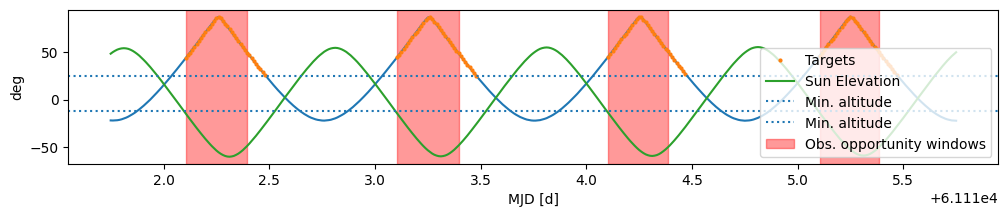

In [269]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 2))
plt.plot(df["MJD"], df["Alt"],)
plt.plot(_df["MJD"], _df["Alt"], "o", ms=2, label="Targets")
plt.plot(df["MJD"], df["Sun_elev"], label="Sun Elevation")
plt.axhline(MINH, linestyle="dotted", label="Min. altitude")
plt.axhline(TWILIGHTS[PHASE], linestyle="dotted", label="Min. altitude")
label_set = False
for s, e in windows:
    plt.axvspan(s, e, label="Obs. opportunity windows" if not label_set else "", color="red", alpha=0.4)
    label_set = True
plt.xlabel("MJD [d]"); plt.ylabel("deg"); plt.legend(loc=4)
plt.show()